<a href="https://colab.research.google.com/github/madsivam05/ML_regression_solarpower/blob/main/solar_power.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing libraries


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import joblib

LOAD DATASET

In [2]:
df=pd.read_csv("solar_power_output.csv")
df.head()
df.tail()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
495,18.833806,27.326566,701.391519,6.569552,352.480220
496,24.591403,93.385086,657.541311,9.566146,326.834297
497,11.943366,30.945490,517.144639,0.689580,259.133251
498,34.359870,96.018988,441.807202,0.570547,223.778239
499,34.655269,55.680462,877.000285,2.821871,435.410369


In [3]:
df.isnull().sum()

,0
temperature,0
humidity,0
solar_irradiance,0
wind_speed,0
solar_power_output,0


select features and target variable

In [4]:
X=df[['temperature','humidity','solar_irradiance','wind_speed']]
Y=df['solar_power_output']
X
Y

,solar_power_output
0,128.101772
1,290.911789
2,442.336390
3,380.261988
4,415.931953
...,...
495,352.480220
496,326.834297
497,259.133251
498,223.778239


split the dataset into training nd test sets(80%train,20%test)

In [5]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8,random_state=42)

In [6]:
X_test

,temperature,humidity,solar_irradiance,wind_speed
361,26.082205,56.263107,289.595970,6.561618
73,30.386536,69.766936,116.086541,8.627971
374,11.779716,22.030908,322.507967,7.328015
155,16.051382,30.206424,777.444976,9.369578
104,32.689162,29.650870,995.417040,0.694238
...,...,...,...,...
347,11.132600,99.749940,433.934887,1.974705
86,28.240154,26.069066,652.070250,6.951446
75,28.225179,95.961650,484.995820,0.957146
438,27.656056,29.420087,281.668107,4.982557


In [7]:
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

predicting the solar power output on yhe test set

In [11]:
y_pred=model.predict(X_test)
y_pred




evaluate the model performance

In [13]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.0
R-squared: 1.0


Visualization

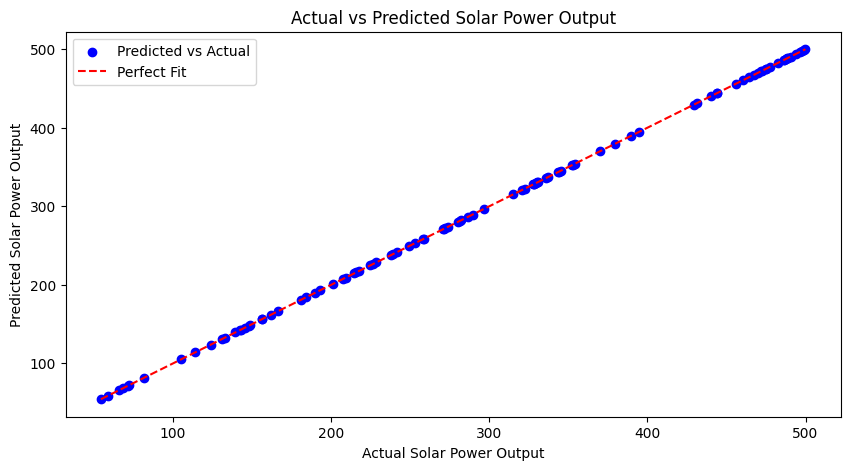

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Solar Power Output")
plt.ylabel("Predicted Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output")
plt.legend()
plt.show()

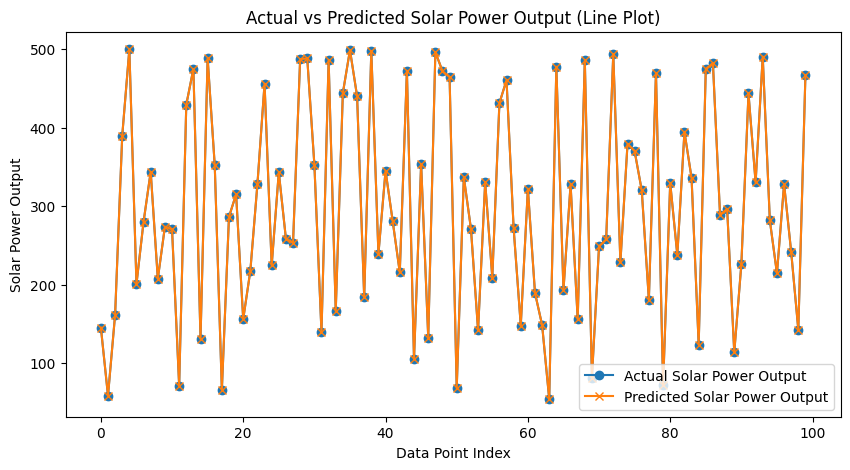

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label="Actual Solar Power Output", marker='o')
plt.plot(range(len(y_test)), y_pred, label="Predicted Solar Power Output", marker='x')
plt.xlabel("Data Point Index")
plt.ylabel("Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output (Line Plot)")
plt.legend()
plt.show()

In [16]:
joblib.dump(model, 'solar_power_prediction_model.pkl')

['solar_power_prediction_model.pkl']

In [17]:
model = joblib. load("solar_power_prediction_model.pkl")
new_data = np.array([[19.36, 75.85,266.61,5.19]])
predicted_output = model.predict(new_data)
print(f"Predicted Solar Power Output: {predicted_output[0]} watts")

Predicted Solar Power Output: 132.6167057318903 watts


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
